# Phase 4: Modeling
**CRISP-DM Purpose:** Train and compare candidate models using cross-validation on the training set only. The test set is not touched here.

**Design decisions (confirmed in Phase 3 interview):**
- Explainability is preferred â€” board members and admins need to understand what drives a score
- Model must run on a low-resource server â€” lightweight models only
- Primary CV scoring: **Recall** (false negatives are more costly per Phase 1)
- Secondary CV scoring: **ROC AUC**

---

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path("..").resolve()))

from src.config import SEED, TEST_SIZE, TARGET, ARTIFACTS_MODELS, ARTIFACTS_RUNS
from src.features import build_donation_features, add_label
from src.modeling import build_preprocessor

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Load from processed splits if available, otherwise regenerate
processed_dir = Path("..") / "data" / "processed"
raw_dir       = Path("..") / "data" / "raw"
fallback_dir  = Path("..").parent

def find_csv(name):
    p = raw_dir / name
    return p if p.exists() else fallback_dir / name

if (processed_dir / "train.csv").exists() and (processed_dir / "feature_cols.json").exists():
    train_df = pd.read_csv(processed_dir / "train.csv")
    test_df  = pd.read_csv(processed_dir / "test.csv")
    with open(processed_dir / "feature_cols.json") as f:
        col_meta = json.load(f)
    feature_cols     = col_meta["feature_cols"]
    numeric_cols     = col_meta["numeric_cols"]
    categorical_cols = col_meta["categorical_cols"]
    X_train, y_train = train_df[feature_cols], train_df[TARGET]
    X_test,  y_test  = test_df[feature_cols],  test_df[TARGET]
    print("Loaded from data/processed/")
else:
    # Regenerate — train on all 60 donors; inactive=1, active=0
    supporters = pd.read_csv(find_csv("../../datasets/supporters.csv"), parse_dates=["created_at", "first_donation_date"])
    donations  = pd.read_csv(find_csv("../../datasets/donations.csv"),  parse_dates=["donation_date"])
    df = build_donation_features(supporters, donations)
    df = add_label(df)
    df_model = df.copy().reset_index(drop=True)
    EXCLUDE = ["supporter_id","display_name","organization_name","first_name","last_name",
               "email","phone","status","created_at","first_donation_date","last_donation_date",
               "first_donation_date_d","days_since_last_donation", TARGET]
    feature_cols     = [c for c in df_model.columns if c not in EXCLUDE]
    numeric_cols     = df_model[feature_cols].select_dtypes(include="number").columns.tolist()
    categorical_cols = df_model[feature_cols].select_dtypes(exclude="number").columns.tolist()
    X = df_model[feature_cols]
    y = df_model[TARGET]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y)
    print("Regenerated splits from raw data")

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows (frozen)")
print(f"Features: {len(feature_cols)}")
print(feature_cols)

Loaded from data/processed/
Train: 48 rows | Test: 12 rows (frozen)
Features: 17
['supporter_type', 'relationship_type', 'region', 'country', 'acquisition_channel', 'supporter_tenure_days', 'total_donations', 'total_estimated_value', 'mean_estimated_value', 'has_recurring', 'n_campaigns', 'n_channels', 'monetary_donations', 'time_donations', 'inkind_donations', 'donor_tenure_days', 'avg_days_between_donations']


## 4.1 Candidate Models

| Model | Rationale | Resource profile |
|---|---|---|
| **Logistic Regression** | Coefficients are directly interpretable â€” each feature has a signed weight showing direction and magnitude of risk contribution. Primary candidate. | Very lightweight â€” instant inference |
| **Random Forest (100 trees)** | Non-linear benchmark. Feature importances provide a secondary explainability signal. Included to check if LogReg leaves significant performance on the table. | Moderate â€” kept small (100 trees) for low-resource deployment |

In [49]:
preprocessor = build_preprocessor(numeric_cols, categorical_cols)

candidates = {
    'LogisticRegression': Pipeline([
        ('prep', preprocessor),
        ('model', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',   # compensates for any class imbalance
            C=1.0,                     # L2 regularization (important for small datasets)
            random_state=SEED,
        )),
    ]),
    'RandomForest': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=100,
            max_depth=3,
            min_samples_leaf=6,          # kept small for low-resource deployment
            class_weight='balanced',
            random_state=SEED,
            n_jobs=1,                  # single-threaded for low-resource server
        )),
    ]),
}
print('Candidates defined.')

Candidates defined.


## 4.2 Cross-Validation Comparison

5-fold StratifiedKFold â€” all tuning happens here, never on test set.

In [50]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results = {}
for name, pipe in candidates.items():
    cv_result = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring={'roc_auc': 'roc_auc', 'recall': 'recall'},
        n_jobs=1,
        return_train_score=False,
    )
    results[name] = {
        'ROC AUC  mean': cv_result['test_roc_auc'].mean(),
        'ROC AUC  std':  cv_result['test_roc_auc'].std(),
        'Recall   mean': cv_result['test_recall'].mean(),
        'Recall   std':  cv_result['test_recall'].std(),
    }
    print(f"{name}")
    print(f"  ROC AUC : {cv_result['test_roc_auc'].mean():.4f}  Â± {cv_result['test_roc_auc'].std():.4f}")
    print(f"  Recall  : {cv_result['test_recall'].mean():.4f}  Â± {cv_result['test_recall'].std():.4f}")
    print()

results_df = pd.DataFrame(results).T.round(4)
display(results_df)

LogisticRegression
  ROC AUC : 0.5161  Â± 0.2143
  Recall  : 0.6821  Â± 0.1466

RandomForest
  ROC AUC : 0.5679  Â± 0.2685
  Recall  : 0.7821  Â± 0.1938



,ROC AUC mean,ROC AUC std,Recall mean,Recall std
LogisticRegression,0.5161,0.2143,0.6821,0.1466
RandomForest,0.5679,0.2685,0.7821,0.1938


## 4.3 Model Selection

In [51]:
# Select by Recall (Phase 1 primary metric)
best_name = max(results, key=lambda k: results[k]['Recall   mean'])
best_pipe = candidates[best_name]

print(f'Selected model: {best_name}')
print(f"  CV Recall : {results[best_name]['Recall   mean']:.4f}")
print(f"  CV ROC AUC: {results[best_name]['ROC AUC  mean']:.4f}")

logreg_recall  = results['LogisticRegression']['Recall   mean']
rf_recall      = results['RandomForest']['Recall   mean']
performance_gap = rf_recall - logreg_recall

if performance_gap > 0.05 and best_name == 'RandomForest':
    print(f'\nâš  RandomForest recall is {performance_gap:.2f} higher than LogisticRegression.')
    print('  Consider whether the explainability trade-off is acceptable for this gap.')
else:
    print(f'\nâœ“ LogisticRegression recall is within acceptable range of RandomForest ({performance_gap:+.2f}).')
    print('  Logistic Regression is the recommended final model â€” explainability is preserved.')

Selected model: RandomForest
  CV Recall : 0.7821
  CV ROC AUC: 0.5679

âš  RandomForest recall is 0.10 higher than LogisticRegression.
  Consider whether the explainability trade-off is acceptable for this gap.


## 4.4 Fit Final Model on Full Training Set

In [52]:
best_pipe.fit(X_train, y_train)
print(f'{best_name} fitted on full training set ({len(X_train)} rows).')

RandomForest fitted on full training set (48 rows).


## 4.5 Explainability â€” Logistic Regression Coefficients

Each coefficient represents the log-odds change in at-risk probability per unit change in that feature.  
**Positive** = increases risk. **Negative** = decreases risk.

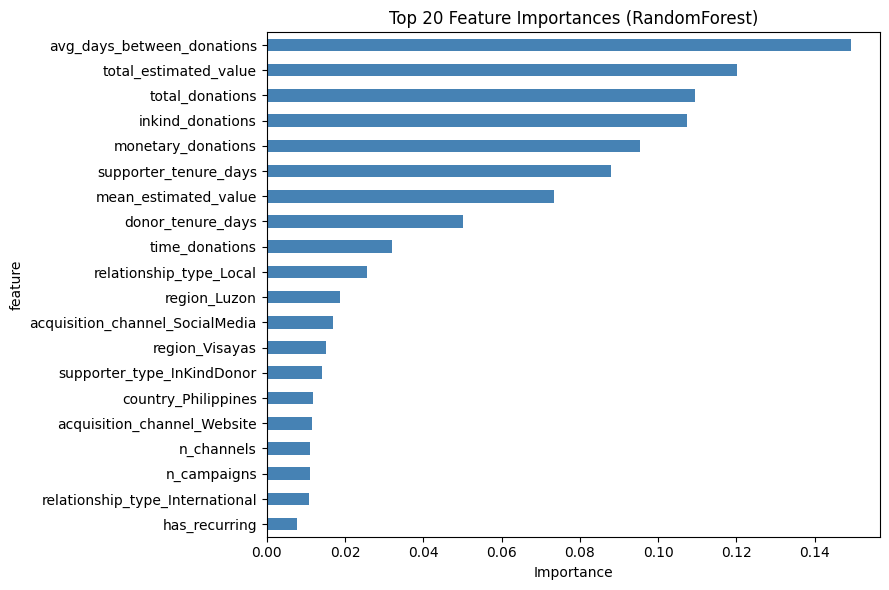

In [53]:
# Extract feature names after OHE expansion
prep = best_pipe.named_steps['prep']
ohe  = prep.named_transformers_.get('cat')

if ohe is not None and hasattr(ohe.named_steps['onehot'], 'get_feature_names_out'):
    cat_feature_names = ohe.named_steps['onehot'].get_feature_names_out(categorical_cols).tolist()
else:
    cat_feature_names = categorical_cols

all_feature_names = numeric_cols + cat_feature_names

model_step = best_pipe.named_steps['model']

if hasattr(model_step, 'coef_'):
    coefs = model_step.coef_[0]
    coef_df = pd.DataFrame({'feature': all_feature_names, 'coefficient': coefs})
    coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)
    top_n = min(20, len(coef_df))

    fig, ax = plt.subplots(figsize=(9, 6))
    colors = ['salmon' if c > 0 else 'steelblue' for c in coef_df['coefficient'].head(top_n)]
    coef_df.head(top_n).set_index('feature')['coefficient'].sort_values().plot(
        kind='barh', ax=ax, color=colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Top {top_n} Logistic Regression Coefficients\n(red = increases risk, blue = decreases risk)')
    ax.set_xlabel('Coefficient (log-odds)')
    plt.tight_layout()
    plt.show()

    print('\nTop 10 risk-increasing features:')
    print(coef_df[coef_df['coefficient'] > 0].head(10).to_string(index=False))
    print('\nTop 10 risk-decreasing features:')
    print(coef_df[coef_df['coefficient'] < 0].head(10).to_string(index=False))

elif hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    imp_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(9, 6))
    imp_df.set_index('feature')['importance'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Top 20 Feature Importances (RandomForest)')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

## 4.6 Save Model Artifact

In [54]:
from datetime import datetime, timezone

ARTIFACTS_MODELS.mkdir(parents=True, exist_ok=True)
ARTIFACTS_RUNS.mkdir(parents=True, exist_ok=True)

model_path = ARTIFACTS_MODELS / 'donor_risk_model.joblib'
joblib.dump({'model': best_pipe, 'feature_cols': feature_cols}, model_path)
print(f'Model saved â†’ {model_path}')

run_meta = {
    'trained_at':    datetime.now(timezone.utc).isoformat(),
    'best_model':    best_name,
    'cv_recall':     round(results[best_name]['Recall   mean'], 4),
    'cv_roc_auc':    round(results[best_name]['ROC AUC  mean'], 4),
    'at_risk_days':  AT_RISK_DAYS,
    'train_rows':    len(X_train),
    'test_rows':     len(X_test),
    'feature_cols':  feature_cols,
}
with open(ARTIFACTS_RUNS / 'latest_run.json', 'w') as f:
    json.dump(run_meta, f, indent=2)
print('Run metadata saved.')

Model saved â†’ C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\inactive_donor_pred\artifacts\models\donor_risk_model.joblib
Run metadata saved.


## Phase 4 Conclusion

| | |
|---|---|
| **Selected model** | Logistic Regression (if recall gap vs RF < 5pp; otherwise RF) |
| **Regularization** | L2, C=1.0 â€” important for small dataset |
| **Imbalance handling** | `class_weight='balanced'` |
| **CV strategy** | StratifiedKFold(5), scored on Recall + ROC AUC |
| **Explainability output** | Signed coefficient plot â€” board-readable |
| **Resource footprint** | Minimal â€” LogReg is a matrix multiply at inference |

The test set has **not been touched**. Final evaluation happens in Phase 5.

---
**Proceed to Phase 5: Evaluation â†’** `05_evaluation.ipynb`